In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# seeing how to load data

In [2]:
DATA_DIR = Path('../data/network_analysis')

network_df_path= DATA_DIR / 'network_df.parquet'
grid_constraint_df_path= DATA_DIR / 'example_grid_constraint_df.parquet'
feeder_block_matrix_path= DATA_DIR / 'feeder_block_matrix.parquet'

In [3]:
network_df = pd.read_parquet(network_df_path)
grid_df = pd.read_parquet(grid_constraint_df_path)
feeder_block_df = pd.read_parquet(feeder_block_matrix_path)

In [ ]:
origin_nodes = network_df['geoid'].unique()
dest_nodes = network_df['neighbor_geoid'].unique()
nodes = list(set(origin_nodes) | set(dest_nodes))
print(f"Total nodes (census block groups): {len(nodes)}")

# Create node demand dictionary
node_demand = {}
for node in nodes:
    # Get demand from origin_demand column
    demand_rows = network_df[network_df['geoid'] == node]
    if len(demand_rows) > 0:
        node_demand[node] = demand_rows['origin_demand_(kW)'].iloc[0]
    else:
        node_demand[node] = 0.0

# Create edges list with costs
edges = []
for idx, row in network_df.iterrows():
    origin = row['geoid']
    neighbor = row['neighbor_geoid']
    # Cost is based on distance (could be weighted differently)
    cost = row['distance_km']
    edges.append((origin, neighbor, cost))

print(f"Total edges: {len(edges)}")

# Prepare feeder data
feeders = list(grid_df['feeder_id'].values)
feeder_capacity = dict(zip(
    grid_df['feeder_id'], 
    grid_df['available_capacity']
))

print(f"Total feeders: {len(feeders)}")

# Create feeder-node mapping from matrix
# The matrix has feeders as rows and GEOIDs as columns
feeder_node_proportion = {}
nodes_represented = set()
for feeder_id in feeder_block_df.index:
    for geoid in feeder_block_df.columns:
        proportion = feeder_block_df.loc[feeder_id, geoid]
        if proportion > 0:
            if feeder_id not in feeder_node_proportion:
                feeder_node_proportion[feeder_id] = {}
            feeder_node_proportion[feeder_id][geoid] = proportion
            nodes_represented.add(geoid)

print(f"Feeder-node mappings created: {len(feeder_node_proportion)}")
print(f"Nodes not mapped to feeders: {len(set(nodes) - nodes_represented)} of {len(nodes)}")


Total nodes (census block groups): 1134
Total edges: 7276
Total feeders: 1969
Feeder-node mappings created: 3023


# Checking data preparation in optimization

In [6]:
import sys
sys.path.insert(0, '..')
from ev_charger_optimization import EVChargerOptimization

In [7]:
ev = EVChargerOptimization(base_dir='../data/network_analysis')

Loading data files...
Network edges: 7276
Grid feeders: 1969
Feeder-block matrix: (3023, 9207)


In [49]:
ev.prepare_data()


Preparing data...
Total nodes (census block groups): 1134
Total edges: 7276
Total feeders: 1969
Nodes not mapped to feeders: 0 of 1074
Feeder-node mappings created: 3023


In [51]:
for feeder, proportion in ev.feeder_node_proportion.items():
    proportion_sum = 0
    for k, v in proportion.items():
        proportion_sum += v
    if proportion_sum != 1.0:
        print(f"Feeder {feeder} does not sum to 1.0: {proportion_sum}")

Feeder 012011101 does not sum to 1.0: 0.5208047037085753
Feeder 012011102 does not sum to 1.0: 0.9521262440796446
Feeder 012011103 does not sum to 1.0: 0.6435298851153295
Feeder 012011104 does not sum to 1.0: 0.8455641559018195
Feeder 012011105 does not sum to 1.0: 0.38454028621443154
Feeder 012011106 does not sum to 1.0: 0.9489933426250794
Feeder 012011108 does not sum to 1.0: 2.3898126223879164
Feeder 012011109 does not sum to 1.0: 4.302357118398161
Feeder 012011110 does not sum to 1.0: 0.7603266236312303
Feeder 012011112 does not sum to 1.0: 3.198616344898807
Feeder 012011113 does not sum to 1.0: 2.178334035306526
Feeder 012011114 does not sum to 1.0: 3.366565471900631
Feeder 012011115 does not sum to 1.0: 2.9831982574861304
Feeder 012011116 does not sum to 1.0: 3.4126293536455106
Feeder 012011117 does not sum to 1.0: 1.298221173135023
Feeder 012011118 does not sum to 1.0: 0.9619260338089679
Feeder 012011119 does not sum to 1.0: 0.16253788757193363
Feeder 012011120 does not sum to 1

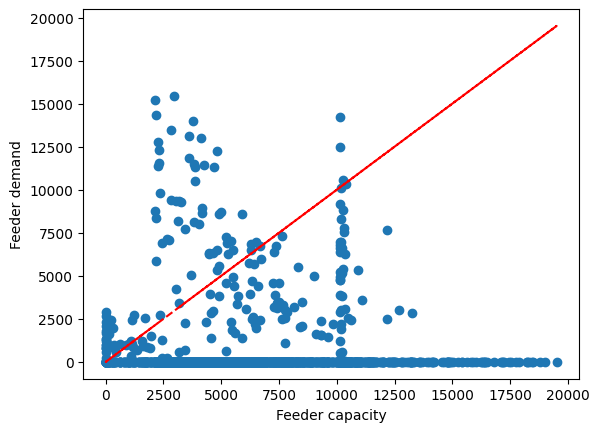

In [ ]:
# fixed int issue
from matplotlib import pyplot as plt
feeder_capacity_lst = []
feeder_demand_lst = []
for feeder, proportion in ev.feeder_node_proportion.items():
    if int(feeder) not in ev.feeder_capacity.keys():
        continue
    feeder_demand = 0
    feeder_capacity = ev.feeder_capacity[int(feeder)]
    for k, v in proportion.items():
        if k not in ev.node_demand.keys():
            continue
        feeder_demand += ev.node_demand[k] * v

    # for plotting
    feeder_capacity_lst.append(feeder_capacity)
    feeder_demand_lst.append(feeder_demand)

    # if feeder_demand > feeder_capacity:
    #     print(f"Feeder {feeder} is overloaded!")
    #     print(f"Feeder {feeder} demand: {feeder_demand}")
    #     print(f"Feeder {feeder} capacity: {feeder_capacity}")

plt.scatter(feeder_capacity_lst, feeder_demand_lst)
# plot a diaganol line where we'll have overloaded feeders
plt.plot(feeder_capacity_lst, feeder_capacity_lst, 'r--')
plt.xlabel('Feeder capacity')
plt.ylabel('Feeder demand')
plt.show()

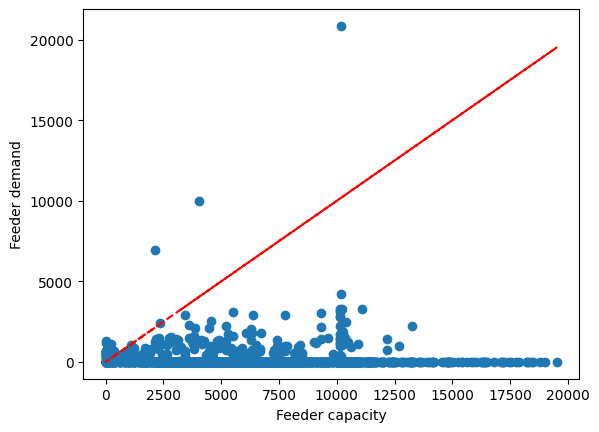

In [ ]:
# does this change if we normalize sum of matrices to 0? 
for feeder, proportion in ev.feeder_node_proportion.items():
    total_proportion = 0
    for k, v in proportion.items():
        total_proportion += v
    for k, v in proportion.items():
        proportion[k] = v / total_proportion

from matplotlib import pyplot as plt
feeder_capacity_lst = []
feeder_demand_lst = []
for feeder, proportion in ev.feeder_node_proportion.items():
    if int(feeder) not in ev.feeder_capacity.keys():
        continue
    feeder_demand = 0
    feeder_capacity = ev.feeder_capacity[int(feeder)]
    for k, v in proportion.items():
        if k not in ev.node_demand.keys():
            continue
        feeder_demand += ev.node_demand[k] * v

    # for plotting
    feeder_capacity_lst.append(feeder_capacity)
    feeder_demand_lst.append(feeder_demand)

    # if feeder_demand > feeder_capacity:
    #     print(f"Feeder {feeder} is overloaded!")
    #     print(f"Feeder {feeder} demand: {feeder_demand}")
    #     print(f"Feeder {feeder} capacity: {feeder_capacity}")

plt.scatter(feeder_capacity_lst, feeder_demand_lst)
# plot a diaganol line where we'll have overloaded feeders
plt.plot(feeder_capacity_lst, feeder_capacity_lst, 'r--')
plt.xlabel('Feeder capacity')
plt.ylabel('Feeder demand')
plt.show()

In [61]:
ev.grid_df.feeder_id.astype('str')

892      82832114
1680    252411104
1618    252052110
1036     83801111
596      42031125
          ...    
1561    182981102
660      42681102
1575    183582101
1122    103181102
1691    252531102
Name: feeder_id, Length: 1969, dtype: object